# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [1]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

SEED = 42


In [2]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [3]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
inventario = pd.DataFrame({
    "tipo_dato": df.dtypes,
    "valores_unicos": df.nunique(),
    "nulos": df.isnull().sum(),
    "pct_nulos": (df.isnull().mean() * 100).round(2)
})
inventario

,tipo_dato,valores_unicos,nulos,pct_nulos
id,int64,5110,0,0.00
gender,str,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,str,2,0,0.00
work_type,str,5,0,0.00
Residence_type,str,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


In [4]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.

IDENT     = "id"
NOMINALES = ["gender", "work_type", "smoking_status"]
BINARIAS  = ["ever_married", "Residence_type"]
INDICADOR = ["hypertension", "heart_disease"]
NUMERICAS = ["age", "avg_glucose_level", "bmi"]
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")

Categorias de cada variable de texto:
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*
`gender` tiene la categoría "Other" con un solo paciente, así que casi no sirve de nada. `smoking_status` tiene la categoría "Unknown", que no dice si el paciente fuma o no, solo que no se sabe.

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [5]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
dup_exactos = df.duplicated().sum()
dup_sin_folio = df.drop(columns=[IDENT]).duplicated().sum()

llave_clinica = NOMINALES + BINARIAS + INDICADOR + ["age"]
dup_llave = df.duplicated(subset=llave_clinica, keep=False)

print(f"Duplicados exactos (todas las columnas): {dup_exactos}")
print(f"Duplicados ignorando folio: {dup_sin_folio}")
print(f"Filas que comparten llave clinica (nivel 3): {dup_llave.sum()}")
print(f"Perfiles clinicos distintos involucrados: {df.loc[dup_llave, llave_clinica].drop_duplicates().shape[0]}")

Duplicados exactos (todas las columnas): 0
Duplicados ignorando folio: 0
Filas que comparten llave clinica (nivel 3): 3310
Perfiles clinicos distintos involucrados: 1019


In [7]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave_clinica_completa = llave_clinica + ["bmi", "avg_glucose_level"]
dup_llave_completa = df.duplicated(subset=llave_clinica_completa, keep=False)
print(f"Filas con mismo perfil clinico + mediciones: {dup_llave_completa.sum()}")

ejemplo = df[dup_llave].sort_values(llave_clinica).head(6)
print(ejemplo)

filas_antes = len(df)
print(f"Filas eliminadas: {filas_antes - len(df)}")



Filas con mismo perfil clinico + mediciones: 0
         id  gender   age  hypertension  heart_disease ever_married work_type Residence_type  avg_glucose_level   bmi  \
2586  41175  Female  22.0             0              0           No  Govt_job          Urban             123.23  21.3   
4306  34415  Female  22.0             0              0           No  Govt_job          Urban              79.57  31.8   
4340  44662  Female  45.0             0              0          Yes  Govt_job          Rural              95.24  40.2   
4641  44233  Female  45.0             0              0          Yes  Govt_job          Rural              84.99  35.4   
1788  17926  Female  48.0             0              0          Yes  Govt_job          Rural             111.64  27.9   
2492  65324  Female  48.0             0              0          Yes  Govt_job          Rural              75.91  27.8   

     smoking_status  stroke  
2586        Unknown       0  
4306        Unknown       0  
4340        Unk

**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:*
Eliminé 0 filas: aunque dup_llave_completa mostró casos con el mismo perfil clínico, sus valores de bmi y avg_glucose_level son distintos, lo que indica pacientes diferentes y no un registro duplicado.

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [8]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("Nulos declarados por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

n_unknown = (df["smoking_status"] == "Unknown").sum()
print(f"\nRegistros con smoking_status = 'Unknown': {n_unknown}")

bmi_presente = df[df["bmi"].notna()]
bmi_ausente  = df[df["bmi"].isna()]

comparacion = pd.DataFrame({
    "bmi_presente": [bmi_presente[OBJETIVO].mean(), bmi_presente["age"].mean()],
    "bmi_ausente":  [bmi_ausente[OBJETIVO].mean(),  bmi_ausente["age"].mean()]
}, index=["tasa_stroke", "edad_media"])
comparacion

Nulos declarados por columna:
bmi    201
dtype: int64

Registros con smoking_status = 'Unknown': 1544


,bmi_presente,bmi_ausente
tasa_stroke,0.042575,0.199005
edad_media,42.865374,52.049154


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:*
No, no falta al azar. Los pacientes sin bmi tienen una tasa de ictus mucho más alta (casi 5 veces más) y son en promedio 9 años mayores. Probablemente a los pacientes más grandes o más enfermos no siempre les toman el peso y la talla en la consulta. Por eso no basta con solo rellenar el dato, también dejé una columna que marca quién no lo tenía.

In [9]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
prop_unknown_worktype = df.groupby("work_type")["smoking_status"].apply(lambda s: (s == "Unknown").mean())
print("Proporcion de 'Unknown' por work_type:")
print(prop_unknown_worktype)

bins = [0, 18, 40, 60, 120]
labels = ["0-18", "19-40", "41-60", "61+"]
df["_grupo_edad_tmp"] = pd.cut(df["age"], bins=bins, labels=labels)

prop_unknown_edad = df.groupby("_grupo_edad_tmp", observed=True)["smoking_status"].apply(lambda s: (s == "Unknown").mean())
print("\nProporcion de 'Unknown' por grupo de edad:")
print(prop_unknown_edad)

df.drop(columns=["_grupo_edad_tmp"], inplace=True)

Proporcion de 'Unknown' por work_type:
work_type
Govt_job         0.185693
Never_worked     0.363636
Private          0.218803
Self-employed    0.190476
children         0.899563
Name: smoking_status, dtype: float64

Proporcion de 'Unknown' por grupo de edad:
_grupo_edad_tmp
0-18     0.774017
19-40    0.216867
41-60    0.194622
61+      0.186350
Name: smoking_status, dtype: float64


        observados  imputacion_global  imputacion_condicionada
count  4909.000000        5110.000000              5110.000000
mean     28.893237          28.862035                28.870822
std       7.854067           7.699562                 7.720488
skew      1.055340           1.088187                 1.070254


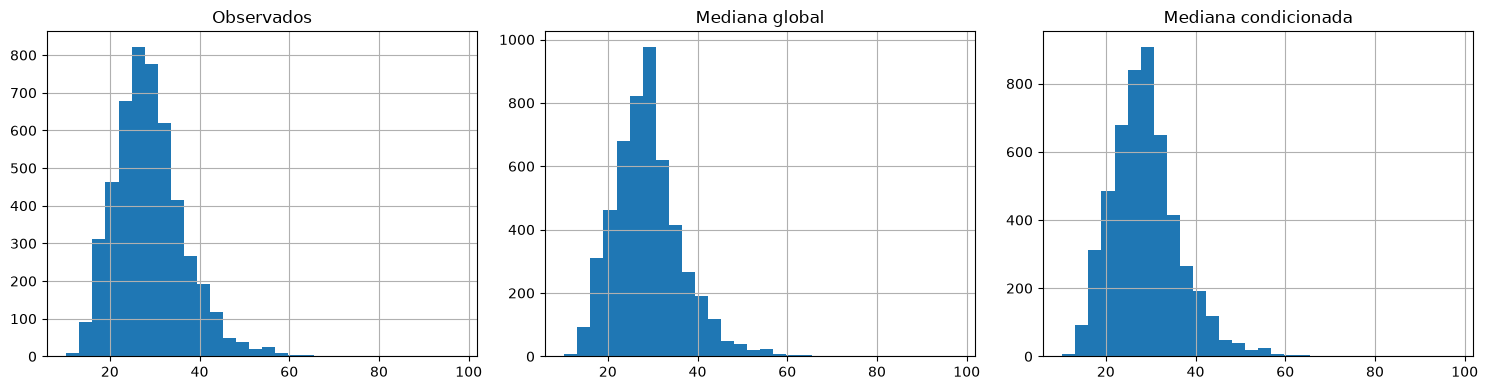


Nulos restantes en bmi: 0


In [10]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
# (a) indicador ANTES de imputar
df["bmi_faltante"] = df["bmi"].isna().astype(int)

# (b) dos versiones
mediana_global = df["bmi"].median()
bmi_imputado_global = df["bmi"].fillna(mediana_global)

grupo_tmp = pd.cut(df["age"], bins=bins, labels=labels)
medianas_cond = df.groupby([grupo_tmp, "gender"], observed=True)["bmi"].transform("median")
bmi_imputado_cond = df["bmi"].fillna(medianas_cond).fillna(mediana_global)

# (c) comparacion
resumen = pd.DataFrame({
    "observados": df["bmi"].dropna().agg(["count", "mean", "std", "skew"]),
    "imputacion_global": bmi_imputado_global.agg(["count", "mean", "std", "skew"]),
    "imputacion_condicionada": bmi_imputado_cond.agg(["count", "mean", "std", "skew"]),
})
print(resumen)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["bmi"].dropna().hist(ax=axes[0], bins=30); axes[0].set_title("Observados")
bmi_imputado_global.hist(ax=axes[1], bins=30); axes[1].set_title("Mediana global")
bmi_imputado_cond.hist(ax=axes[2], bins=30); axes[2].set_title("Mediana condicionada")
plt.tight_layout()
plt.show()

# (d) eleccion: mediana condicionada (preserva mejor la dispersion real)
df["bmi"] = bmi_imputado_cond
print(f"\nNulos restantes en bmi: {df['bmi'].isnull().sum()}")

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*
Al rellenar los datos que faltaban, la desviación estándar baja un poco, porque estamos metiendo valores "promedio" donde antes había variedad real. Usé la mediana según edad y sexo porque se acerca más a los datos reales que usar una sola mediana para todos. La columna `bmi_faltante` sirve para no perder la pista de que faltar el dato ya dice algo (esos pacientes tienen más riesgo). Y la categoría "Unknown" de fumar la dejé tal cual, no la rellené, porque parece ser algo real (sobre todo en niños) y no un dato perdido al azar.

---
## Parte 4 · Valores atípicos (subtema 4.3)

age                  limites=(-29.00, 115.00)  atipicos=0  max=82.00
avg_glucose_level    limites=(21.98, 169.36)  atipicos=627  max=271.74
bmi                  limites=(10.05, 46.45)  atipicos=123  max=97.60


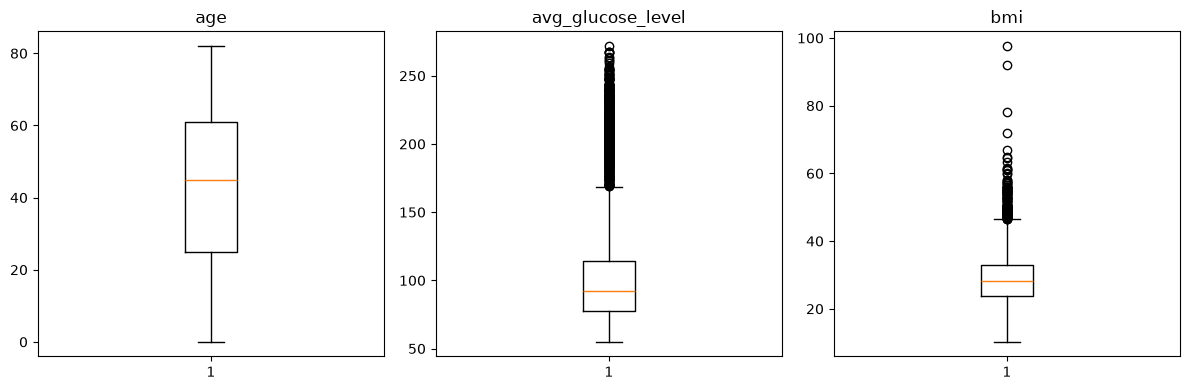

In [11]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in NUMERICAS:
    li, ls = limites_iqr(df[col])
    n_atipicos = ((df[col] < li) | (df[col] > ls)).sum()
    print(f"{col:<20} limites=({li:.2f}, {ls:.2f})  atipicos={n_atipicos}  max={df[col].max():.2f}")

fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(4*len(NUMERICAS), 4))
for ax, col in zip(axes, NUMERICAS):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [12]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
li_bmi, ls_bmi = limites_iqr(df["bmi"])
dentro = df[df["bmi"] <= ls_bmi]
fuera  = df[df["bmi"] > ls_bmi]

print(f"Tasa de stroke con bmi <= limite superior ({ls_bmi:.2f}): {dentro[OBJETIVO].mean():.4f}")
print(f"Tasa de stroke con bmi >  limite superior: {fuera[OBJETIVO].mean():.4f}")
print(f"Registros con bmi > 60: {(df['bmi'] > 60).sum()}")
print(f"Maximo bmi observado: {df['bmi'].max():.2f}")

asimetria_original = df["bmi"].skew()
p99 = df["bmi"].quantile(0.99)
bmi_winsor = df["bmi"].clip(upper=p99)
asimetria_winsor = bmi_winsor.skew()

print(f"\nAsimetria original: {asimetria_original:.3f}")
print(f"Asimetria tras winsorizar al p99: {asimetria_winsor:.3f}")

Tasa de stroke con bmi <= limite superior (46.45): 0.0493
Tasa de stroke con bmi >  limite superior: 0.0244
Registros con bmi > 60: 13
Maximo bmi observado: 97.60

Asimetria original: 1.070
Asimetria tras winsorizar al p99: 0.674


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:*
Decidí recortar los valores muy altos de bmi (no borrarlos). Hay 13 pacientes con bmi arriba de 60, pero no tienen más riesgo de ictus que los demás, así que no parecen errores, son casos reales de obesidad severa. En la práctica pasada, un colesterol de 0 era imposible y por eso se borraba sin pensarlo mucho; aquí un bmi alto sí puede ser real, entonces hay que decidir con más cuidado. Esto también significa que en la Parte 8 voy a usar un escalador que no se deje afectar tanto por esos valores extremos.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [13]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
df["imc_cat"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf],
                        labels=["bajo_peso", "normal", "sobrepeso", "obesidad"])

df["glucosa_cat"] = pd.cut(df["avg_glucose_level"], bins=[0, 140, 200, np.inf],
                            labels=["normal", "prediabetes", "diabetes"])

df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]

df["grupo_edad"] = pd.cut(df["age"], bins=bins, labels=labels)

for col in ["imc_cat", "glucosa_cat", "n_comorbilidades", "grupo_edad"]:
    tabla = df.groupby(col, observed=True)[OBJETIVO].agg(["count", "mean"])
    print(f"\n{col}:")
    print(tabla)


imc_cat:
           count      mean
imc_cat                   
bajo_peso    349  0.002865
normal      1279  0.029711
sobrepeso   1558  0.069961
obesidad    1924  0.052495

glucosa_cat:
             count      mean
glucosa_cat                 
normal        4289  0.036372
prediabetes    387  0.095607
diabetes       434  0.129032

n_comorbilidades:
                  count      mean
n_comorbilidades                 
0                  4400  0.033864
1                   646  0.134675
2                    64  0.203125

grupo_edad:
            count      mean
grupo_edad                 
0-18          916  0.002183
19-40        1328  0.004518
41-60        1562  0.040973
61+          1304  0.135736


**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:*
Usé los cortes que ya existen en medicina: los de bmi (18.5/25/30) y los de glucosa (140/200 mg/dL) para diabetes. La categoría de glucosa, la de edad y la de comorbilidades sí van subiendo el riesgo de forma pareja conforme suben de categoría. La de bmi no: el riesgo baja un poco en "obesidad" comparado con "sobrepeso", lo cual es raro y probablemente se debe a otras variables de por medio. También noté que mi variable de grupo de edad es básicamente lo mismo que la edad normal, solo que en categorías — eso lo voy a tener que tomar en cuenta más adelante.

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [14]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

cols_ohe = NOMINALES + BINARIAS

for drop_mode in [None, "first", "if_binary"]:
    ohe_tmp = OneHotEncoder(drop=drop_mode, sparse_output=False, handle_unknown="ignore")
    ohe_tmp.fit(df[cols_ohe])
    print(f"drop={str(drop_mode):<10} -> columnas resultantes: {len(ohe_tmp.get_feature_names_out())}")

# Se elige drop="if_binary": evita colinealidad en las binarias sin perder
# columnas informativas en las variables con mas de dos categorias
ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
X_ohe = pd.DataFrame(
    ohe.fit_transform(df[cols_ohe]),
    columns=ohe.get_feature_names_out(cols_ohe),
    index=df.index
)
print(f"\nForma de la matriz codificada: {X_ohe.shape}")

frecuencias = X_ohe.sum().sort_values()
print(f"\nColumna con menor frecuencia: {frecuencias.index[0]} ({int(frecuencias.iloc[0])} registros)")

drop=None       -> columnas resultantes: 16
drop=first      -> columnas resultantes: 11
drop=if_binary  -> columnas resultantes: 14

Forma de la matriz codificada: (5110, 14)

Columna con menor frecuencia: gender_Other (1 registros)


In [15]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
ohe_worktype = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_worktype.fit(df[["work_type"]])

nuevo = pd.DataFrame({"work_type": ["Pensionado"]})
resultado = ohe_worktype.transform(nuevo)
print("Categorias aprendidas:", ohe_worktype.categories_)
print("Codificacion de 'Pensionado':")
print(resultado)
# Con handle_unknown="ignore" la fila queda en ceros.
# Con handle_unknown="error" .transform() habria lanzado ValueError.

Categorias aprendidas: [array(['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children'],
      dtype=object)]
Codificacion de 'Pensionado':
[[0. 0. 0. 0. 0.]]


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:*
En una variable de solo dos opciones (como casado o no), quitar una no pierde nada porque con la otra ya se sabe. En una variable con varias categorías (como tipo de trabajo), quitar una sí puede perder información. Por eso usé `drop='if_binary'`: quita columnas solo donde no hace daño. A la categoría con un solo paciente (`gender_Other`) no la quité a mano aquí; dejé que se eliminara sola más adelante con una regla clara (varianza casi nula), para que la decisión quede documentada y no sea "a ojo".

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [16]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
from scipy.stats import yeojohnson

resultados = []
for col in NUMERICAS:
    x = df[col]
    asim_original = x.skew()
    asim_sqrt = np.sqrt(x.clip(lower=0)).skew()
    asim_log = np.log1p(x.clip(lower=0)).skew()
    x_yj, lam = yeojohnson(x)
    asim_yj = pd.Series(x_yj).skew()
    resultados.append([col, asim_original, asim_sqrt, asim_log, asim_yj, lam])

tabla_asimetria = pd.DataFrame(
    resultados, columns=["variable", "original", "sqrt", "log1p", "yeo_johnson", "lambda_yj"]
).set_index("variable")
tabla_asimetria

,original,sqrt,log1p,yeo_johnson,lambda_yj
variable,,,,,
age,-0.137059,-0.786212,-1.677352,-0.278805,0.860204
avg_glucose_level,1.572284,1.242722,0.889470,0.084574,-1.075924
bmi,1.070254,0.475102,0.021228,-0.000674,-0.024944


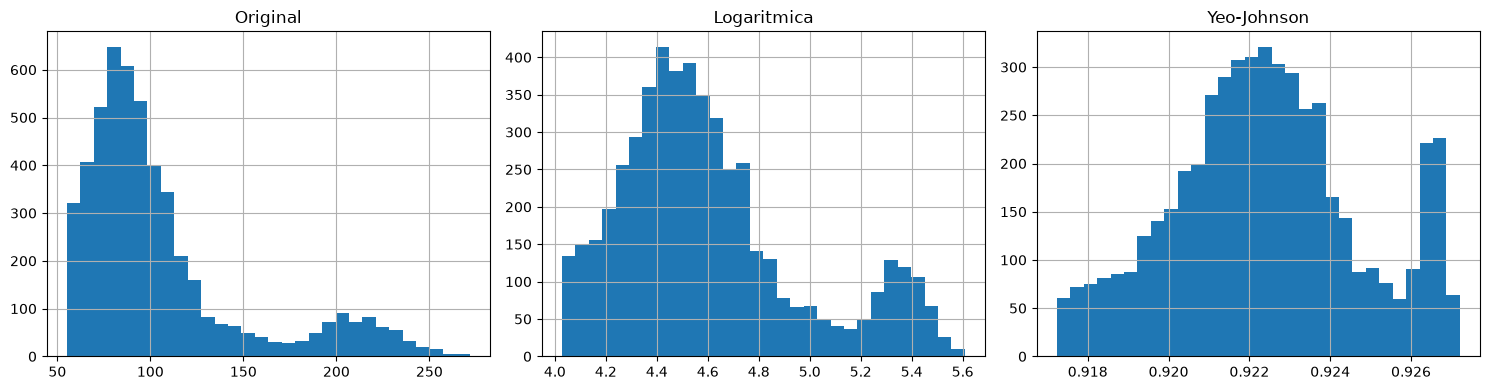

Porcentaje de pacientes por categoria clinica de glucosa:
glucosa_cat
normal         83.93
diabetes        8.49
prediabetes     7.57
Name: proportion, dtype: float64


In [17]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
col = "avg_glucose_level"
x_log = np.log1p(df[col])
x_yj, lam = yeojohnson(df[col])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df[col].hist(ax=axes[0], bins=30); axes[0].set_title("Original")
x_log.hist(ax=axes[1], bins=30); axes[1].set_title("Logaritmica")
pd.Series(x_yj).hist(ax=axes[2], bins=30); axes[2].set_title("Yeo-Johnson")
plt.tight_layout()
plt.show()

pct_categoria = df["glucosa_cat"].value_counts(normalize=True).mul(100).round(2)
print("Porcentaje de pacientes por categoria clinica de glucosa:")
print(pct_categoria)

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:*
`bmi` mejora bastante con el logaritmo, casi queda simétrico. `age` en cambio empeora con el logaritmo: como ya estaba bastante pareja, el logaritmo la deja más torcida en vez de mejorarla. `avg_glucose_level` es la que no se arregla con ninguna transformación: su problema no es que esté torcida, es que en realidad son dos grupos de pacientes distintos mezclados (los que tienen glucosa normal y los diabéticos), y ninguna fórmula matemática puede separar esos dos grupos. Para eso ya tenía la solución hecha desde la Parte 5: la categoría de glucosa.

---
## Parte 8 · Escalamiento (subtema 4.6)

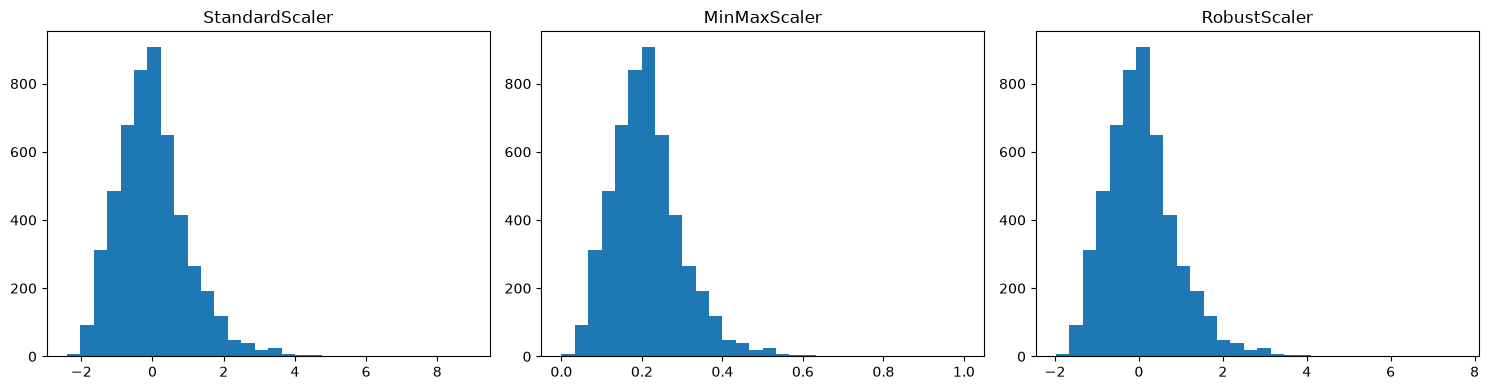

,min,max,amplitud_90pct,asimetria
StandardScaler,-2.405630,8.903052,3.232625,1.070254
MinMaxScaler,0.000000,1.000000,0.285853,1.070254
RobustScaler,-1.978022,7.615385,2.742308,1.070254


In [18]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

escaladores = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler(), "RobustScaler": RobustScaler()}
resultados_escala = {}
bmi_col = df[["bmi"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, escalador) in zip(axes, escaladores.items()):
    x_esc = escalador.fit_transform(bmi_col).flatten()
    resultados_escala[nombre] = {
        "min": x_esc.min(), "max": x_esc.max(),
        "amplitud_90pct": np.percentile(x_esc, 95) - np.percentile(x_esc, 5),
        "asimetria": pd.Series(x_esc).skew()
    }
    ax.hist(x_esc, bins=30); ax.set_title(nombre)
plt.tight_layout()
plt.show()

pd.DataFrame(resultados_escala).T

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:*
La asimetría sale igual en los tres escaladores porque todos hacen lo mismo: cambian la escala de los números pero no cambian la forma de la distribución. Elegí RobustScaler porque usa la mediana en vez del promedio, así que no se deja afectar tanto por los valores extremos de bmi que decidí conservar. No voy a escalar las columnas que ya son 0 y 1 (como hipertensión o las columnas de one-hot), porque escalarlas no cambia nada útil.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [19]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
derivadas_categoricas = ["imc_cat", "glucosa_cat", "grupo_edad"]
ohe_derivadas = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
X_derivadas_ohe = pd.DataFrame(
    ohe_derivadas.fit_transform(df[derivadas_categoricas].astype(str)),
    columns=ohe_derivadas.get_feature_names_out(derivadas_categoricas),
    index=df.index
)

X = pd.concat([
    df[NUMERICAS],
    df[INDICADOR + ["bmi_faltante", "n_comorbilidades"]],
    X_derivadas_ohe,
    X_ohe
], axis=1)

y = df[OBJETIVO]
print("Forma de X:", X.shape)
print("\nColumnas de X:")
print(list(X.columns))

Forma de X: (5110, 32)

Columnas de X:
['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'bmi_faltante', 'n_comorbilidades', 'imc_cat_bajo_peso', 'imc_cat_normal', 'imc_cat_obesidad', 'imc_cat_sobrepeso', 'glucosa_cat_diabetes', 'glucosa_cat_normal', 'glucosa_cat_prediabetes', 'grupo_edad_0-18', 'grupo_edad_19-40', 'grupo_edad_41-60', 'grupo_edad_61+', 'gender_Female', 'gender_Male', 'gender_Other', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'ever_married_Yes', 'Residence_type_Urban']


In [20]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X)

columnas_descartadas_var = X.columns[~vt.get_support()]
print(f"Columnas descartadas por varianza casi nula: {list(columnas_descartadas_var)}")

varianzas = X.var().sort_values()
print("\nCinco varianzas mas bajas:")
print(varianzas.head())

Columnas descartadas por varianza casi nula: ['gender_Other', 'work_type_Never_worked']

Cinco varianzas mas bajas:
gender_Other              0.000196
work_type_Never_worked    0.004288
bmi_faltante              0.037795
heart_disease             0.051104
imc_cat_bajo_peso         0.063645
dtype: float64


In [21]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=SEED)
correlacion = X.apply(lambda col: col.corr(y))

tabla_relevancia = pd.DataFrame({
    "informacion_mutua": mi,
    "correlacion_pearson": correlacion.values
}, index=X.columns).sort_values("informacion_mutua", ascending=False)

tabla_relevancia

,informacion_mutua,correlacion_pearson
age,0.036921,0.245257
grupo_edad_61+,0.025584,0.236550
n_comorbilidades,0.017562,0.174616
grupo_edad_0-18,0.011079,-0.101032
glucosa_cat_diabetes,0.009388,0.113633
grupo_edad_19-40,0.008795,-0.121679
bmi,0.007925,0.040488
glucosa_cat_normal,0.007018,-0.131171
ever_married_Yes,0.006788,0.108340
avg_glucose_level,0.005313,0.131945


In [23]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
# (a) age vs columnas one-hot
candidatas = [c for c in ["work_type_children", "grupo_edad_61+"] if c in X.columns]
print("Correlacion de age con variables relacionadas con la edad:")
for c in candidatas:
    print(f"  age vs {c}: {X['age'].corr(X[c]):.3f}")

# (b) continuas vs su version discretizada
print("\nCorrelacion continua vs discretizada:")

grupo_edad_codes = pd.Series(pd.Categorical(df["grupo_edad"]).codes, index=df.index)
imc_cat_codes = pd.Series(pd.Categorical(df["imc_cat"]).codes, index=df.index)
glucosa_cat_codes = pd.Series(pd.Categorical(df["glucosa_cat"]).codes, index=df.index)

print(f"  age vs grupo_edad: {X['age'].corr(grupo_edad_codes):.3f}")
print(f"  bmi vs imc_cat: {X['bmi'].corr(imc_cat_codes):.3f}")
print(f"  avg_glucose_level vs glucosa_cat: {X['avg_glucose_level'].corr(glucosa_cat_codes):.3f}")


# (c) combinacion lineal exacta
diferencia_exacta = (X["n_comorbilidades"] - (X["hypertension"] + X["heart_disease"])).abs().max()
print(f"\nDiferencia maxima entre n_comorbilidades y (hypertension + heart_disease): {diferencia_exacta}")

Correlacion de age con variables relacionadas con la edad:
  age vs work_type_children: -0.634
  age vs grupo_edad_61+: 0.732

Correlacion continua vs discretizada:
  age vs grupo_edad: 0.962
  bmi vs imc_cat: 0.845
  avg_glucose_level vs glucosa_cat: 0.907

Diferencia maxima entre n_comorbilidades y (hypertension + heart_disease): 0


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:*
La variable que más cambia de lugar según el criterio es `bmi_faltante`: con correlación normal sale bastante arriba, pero con información mutua casi no aparece. Eso pasa porque la correlación solo ve relaciones en línea recta, y la información mutua ve cualquier tipo de relación, así que no siempre coinciden. Dos columnas que en el fondo son casi lo mismo que la edad: `grupo_edad` (se parece muchísimo a `age`) y `grupo_edad_61+`. De mis variables nuevas: `n_comorbilidades` la quito porque es exactamente la suma de otras dos columnas que ya están (es la misma trampa de la práctica pasada). `grupo_edad` la quito porque es casi una copia de `age`. `glucosa_cat` la conservo porque sí aporta algo distinto a la glucosa normal. `imc_cat` la dejo solo a medias, porque ya vimos que su relación con el riesgo no es tan clara.

In [24]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
columnas_a_eliminar = list(columnas_descartadas_var) + ["n_comorbilidades"]
X_final = X.drop(columns=[c for c in columnas_a_eliminar if c in X.columns])

escalador_final = RobustScaler()
X_final[NUMERICAS] = escalador_final.fit_transform(X_final[NUMERICAS])

print("Forma final de la matriz de modelado:", X_final.shape)
X_final.head()

Forma final de la matriz de modelado: (5110, 29)


,age,avg_glucose_level,bmi,hypertension,heart_disease,bmi_faltante,imc_cat_bajo_peso,imc_cat_normal,imc_cat_obesidad,imc_cat_sobrepeso,glucosa_cat_diabetes,glucosa_cat_normal,glucosa_cat_prediabetes,grupo_edad_0-18,grupo_edad_19-40,grupo_edad_41-60,grupo_edad_61+,gender_Female,gender_Male,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes,Residence_type_Urban
0,0.611111,3.712987,0.912088,0,1,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.444444,2.994300,0.087912,0,0,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.972222,0.380920,0.461538,0,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.111111,2.153481,0.670330,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,0.944444,2.231917,-0.472527,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.

| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` | No tiene | No aplica | No aplica | No aplica | No aplica | No, es solo un folio |
| `gender` | No tiene | "Other" (1 caso) se elimina por casi no variar | One-hot | No aplica | No aplica | Sí, menos "Other" |
| `age` | No tiene | No tiene | Numérica | No se transforma | RobustScaler | Sí |
| `hypertension` | No tiene | No aplica | Ya es 0/1 | No aplica | No se escala | Sí |
| `heart_disease` | No tiene | No aplica | Ya es 0/1 | No aplica | No se escala | Sí |
| `ever_married` | No tiene | No aplica | One-hot | No aplica | No aplica | Sí |
| `work_type` | No tiene | No aplica | One-hot, se elimina "Never_worked" | No aplica | No aplica | Sí, con ajustes |
| `Residence_type` | No tiene | No aplica | One-hot | No aplica | No aplica | Sí |
| `avg_glucose_level` | No tiene | Se conservan (son reales, no errores) | Numérica + categoría de glucosa | No se puede arreglar (dos grupos mezclados) | RobustScaler | Sí |
| `bmi` | 201 casos, se rellenaron por edad y sexo + columna de "faltaba" | Se recortan los valores muy altos | Numérica + categoría de bmi | El log la mejora mucho | RobustScaler | Sí |
| `smoking_status` | "Unknown" se deja como su propia categoría | No aplica | One-hot | No aplica | No aplica | Sí |
---

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo? Dos filas serían el mismo paciente si además de parecerse en todo también tuvieran el mismo bmi y glucosa exactos, o si hubiera una columna con el número de expediente real del hospital. Aquí `id` solo es un folio de fila, no identifica de verdad a la persona, así que no puedo estar segura sin ese dato extra.

2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente? Los pacientes sin bmi tienen casi 5 veces más riesgo de ictus y son mayores en promedio. Puede ser que a los pacientes más graves no siempre les midan el peso porque están enfocados en atenderlos. Solo rellenar el dato no basta porque se perdería esa pista; por eso dejé la columna que marca a quién le faltaba.


3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia. Los ceros de colesterol eran imposibles biológicamente, por eso ahí la decisión fue fácil (se borraban). La categoría "Unknown" de fumar sí puede ser real, sobre todo en niños a quienes no se les pregunta. Por eso a una la traté como error y a la otra como información válida.


4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide? `avg_glucose_level` no se arregla con ninguna transformación porque el problema no es que esté torcida sino que son dos grupos de pacientes distintos mezclados (normales y diabéticos). Ninguna fórmula matemática separa dos grupos así, por eso mejor hice una categoría aparte para eso.

5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?   Mantendría la idea de guardar la columna de "faltaba bmi", porque con tantos casos sin dato esa información sería aún más valiosa. Pero cambiaría cómo relleno el dato, porque con tan pocos datos completos la mediana por grupos ya no sería confiable; buscaría una forma más robusta de estimarlo.

6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas. Una categoría nueva sirve si dice algo que la variable original no decía (como la categoría de diabetes, que marca un límite clínico real). Es redundante si es casi una copia de la variable original, como pasó con mi grupo de edad, que terminé quitando porque era casi lo mismo que la edad normal.

